# 🚀 Boosting — From Scratch to Production
### A Complete ML Learning Resource

---

## 📋 Learning Objectives

By the end of this notebook you will be able to:

1. **Explain** the core intuition behind Boosting — sequential error correction via weak learners.
2. **Implement** AdaBoost from scratch using NumPy — weight updates, alpha computation, weighted error.
3. **Implement** Gradient Boosted Trees using Scikit-Learn's `GradientBoostingClassifier`.
4. **Tune** key hyperparameters (`n_estimators`, `learning_rate`, `max_depth`) with cross-validation.
5. **Interpret** model outputs using feature importances and visualize performance curves.
6. **Answer** FAANG-level interview questions on Boosting with structured, confident responses.

---

## ✅ Prerequisites

- Python, NumPy, Pandas
- Decision Trees (CART, Gini impurity, splits)
- Bias–Variance Tradeoff
- Binary Classification metrics (Accuracy, AUC, Log Loss)
- Basic familiarity with Scikit-Learn API

---

## 📦 Dataset: Pima Indians Diabetes Dataset

**Source:** [Kaggle — Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

**Why this dataset?**
- Real clinical data from the National Institute of Diabetes and Digestive and Kidney Diseases.
- Binary classification target (diabetic / not diabetic) — a natural Boosting use-case.
- Contains meaningful features (glucose, BMI, age) with real-world quirks (zero values as proxies for missing data).
- Small and clean enough to run fast; complex enough to show Boosting's power over simpler baselines.

**Features:** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age  
**Target:** `Outcome` — 0 (non-diabetic) or 1 (diabetic)

---

## 📚 Credits & References

| Resource | Link |
|---|---|
| Original AdaBoost Paper (Freund & Schapire, 1997) | [ScienceDirect](https://www.sciencedirect.com/science/article/pii/S002200009791504X) |
| Gradient Boosting Paper (Friedman, 2001) | [Project Euclid](https://projecteuclid.org/journals/annals-of-statistics/volume-29/issue-5/Greedy-function-approximation-A-gradient-boosting-machine/10.1214/aos/1013203451.full) |
| StatQuest Gradient Boost Series | [YouTube](https://www.youtube.com/watch?v=3CC4N4z3GJc) |
| Scikit-Learn GBM Docs | [sklearn.ensemble](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting) |

---
> 📌 **Note:** This notebook uses the `diabetes.csv` dataset. Download it from Kaggle and place it in the same directory as this notebook, **OR** run the cell below — it will attempt to load it from a public mirror automatically.


## 📦 Cell 2: Import Libraries

In [1]:
# ── Standard Library ──────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Numerical Computing ────────────────────────────────────────
import numpy as np                          # Core array math; used in from-scratch implementation
import pandas as pd                         # Data loading, EDA, preprocessing

# ── Visualization ──────────────────────────────────────────────
import matplotlib.pyplot as plt             # Base plotting engine
import seaborn as sns                       # Statistical visualizations (heatmaps, distributions)
sns.set_theme(style="whitegrid", palette="muted")  # Consistent professional style

# ── Scikit-Learn: Preprocessing ───────────────────────────────
from sklearn.model_selection import (
    train_test_split,                       # Hold-out split
    cross_val_score,                        # K-fold cross-validation
    StratifiedKFold                         # Preserves class ratio across folds (important for imbalanced data)
)
from sklearn.preprocessing import StandardScaler  # Feature scaling (used in scratch model)
from sklearn.metrics import (
    accuracy_score,                         # Fraction of correct predictions
    roc_auc_score,                          # Area under ROC curve — preferred for imbalanced binary classification
    classification_report,                  # Precision, Recall, F1 per class
    confusion_matrix,                       # True/False Positive/Negative breakdown
    roc_curve                               # For plotting the ROC curve
)

# ── Scikit-Learn: Ensemble Models ─────────────────────────────
from sklearn.ensemble import (
    GradientBoostingClassifier,             # Sklearn's GBM — our library-based Boosting implementation
    AdaBoostClassifier                      # For comparison and sanity-check
)
from sklearn.tree import DecisionTreeClassifier  # Weak learner used inside our scratch AdaBoost

# ── Random Seed — ensures reproducibility across all experiments ──
np.random.seed(42)

print("✅ All libraries imported successfully.")
print(f"   NumPy     : {np.__version__}")
print(f"   Pandas    : {pd.__version__}")
print(f"   Sklearn   : {__import__('sklearn').__version__}")


✅ All libraries imported successfully.
   NumPy     : 2.4.4
   Pandas    : 3.0.2
   Sklearn   : 1.8.0


---
## 📖 Part 1: Theory Recap

### What Is Boosting?

Boosting converts a sequence of **weak learners** (models barely better than random chance) into a **strong learner** through sequential, error-correcting training. Each new model focuses on the mistakes of the current ensemble — either by upweighting misclassified samples (AdaBoost) or by fitting the negative gradient of the loss function (Gradient Boosting).

---

### 5 Key Ideas You Must Know

1. **Sequential Additive Model**  
   The final prediction is a weighted sum of weak learners:  
   `F_T(x) = Σ αₜ · hₜ(x)`  
   Each hₜ is a shallow tree; αₜ is its earned trust (higher when error is lower).

2. **AdaBoost: Sample Reweighting**  
   After each round, misclassified samples receive exponentially larger weights.  
   The next learner is forced to concentrate on those harder examples.  
   Weight update: `wᵢ ← wᵢ · exp(−αₜ · yᵢ · hₜ(xᵢ))`

3. **Gradient Boosting: Functional Gradient Descent**  
   Instead of reweighting samples, GBM computes the **negative gradient of the loss** (pseudo-residuals) and fits the next tree to those residuals.  
   This generalizes Boosting to any differentiable loss — regression, classification, ranking.

4. **Learning Rate as Regularization**  
   Each tree's contribution is scaled by η (learning rate): `Fₜ(x) = Fₜ₋₁(x) + η · hₜ(x)`.  
   Small η → more trees needed, but better generalization (shrinkage effect).

5. **Why Boosting Primarily Reduces Bias**  
   Each round corrects systematic errors. Unlike Bagging (which averages parallel models to reduce variance), Boosting iteratively drives the ensemble toward the true decision boundary — which is why it excels on structured/tabular data.

---

> 🔑 **Interview Anchor:** Boosting = functional gradient descent in model-output space. AdaBoost is a special case under exponential loss.


---
## 📊 Cell 4: Load & Explore the Dataset

We load the **Pima Indians Diabetes Dataset** — a real clinical dataset.  
The goal: predict whether a patient has diabetes (`Outcome=1`) based on 8 physiological measurements.

We inspect:
- `.head()` — first 5 rows to sanity-check structure
- `.info()` — data types and null counts
- `.describe()` — statistical summary (critical for spotting zero-valued missings)


In [2]:
# ── Load Dataset ──────────────────────────────────────────────
# Primary: try local file (user downloaded from Kaggle)
# Fallback: public mirror (UCI via GitHub)
import os

LOCAL_PATH = "diabetes.csv"
MIRROR_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
MIRROR_COLS = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
    print(f"✅ Loaded local file: {LOCAL_PATH}")
else:
    print("⚠️  Local file not found. Fetching from public mirror...")
    df = pd.read_csv(MIRROR_URL, header=None, names=MIRROR_COLS)
    print("✅ Loaded from mirror.")

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n── First 5 Rows ─────────────────────────────────────────")
df.head()


⚠️  Local file not found. Fetching from public mirror...
✅ Loaded from mirror.

Dataset Shape: 768 rows × 9 columns

── First 5 Rows ─────────────────────────────────────────


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# ── Data Types & Null Check ────────────────────────────────────
print("── .info() ─────────────────────────────────────────────────")
df.info()


── .info() ─────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# ── Statistical Summary ────────────────────────────────────────
# KEY OBSERVATION: Features like Glucose, BloodPressure, SkinThickness, Insulin, BMI
# have MINIMUM = 0, which is physiologically impossible.
# These zeros are actually missing values encoded as 0 — a common real-world data issue.
print("── .describe() ─────────────────────────────────────────────")
df.describe().round(2)


── .describe() ─────────────────────────────────────────────


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [5]:
# ── Target Distribution ────────────────────────────────────────
print("── Target Variable: Outcome ─────────────────────────────────")
vc = df['Outcome'].value_counts()
print(vc)
print(f"\nClass balance: {vc[0]} non-diabetic ({vc[0]/len(df)*100:.1f}%) | "
      f"{vc[1]} diabetic ({vc[1]/len(df)*100:.1f}%)")
print("\n⚠️  Mild class imbalance — AUC-ROC is a better metric than raw accuracy.")


── Target Variable: Outcome ─────────────────────────────────
Outcome
0    500
1    268
Name: count, dtype: int64

Class balance: 500 non-diabetic (65.1%) | 268 diabetic (34.9%)

⚠️  Mild class imbalance — AUC-ROC is a better metric than raw accuracy.


---
## 🔧 Cell 5: Data Preprocessing

**Steps we take:**
1. **Replace physiologically-impossible zeros** with column median (domain knowledge driven).
2. **Separate features and target** for clean downstream use.
3. **Train/test split** — stratified to preserve class ratio (important given mild imbalance).
4. **Feature scaling** — StandardScaler for the from-scratch model (decision stumps are scale-sensitive when using weighted error; scaling stabilises numeric stability).


In [6]:
# ── Step 1: Replace Impossible Zeros with Column Median ──────
# Columns where 0 is biologically impossible (not true zero):
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
for col in zero_invalid_cols:
    n_zeros = (df_clean[col] == 0).sum()
    median_val = df_clean[col][df_clean[col] != 0].median()  # Median of non-zero values
    df_clean[col] = df_clean[col].replace(0, median_val)
    print(f"  {col:28s}: replaced {n_zeros:3d} zeros → median = {median_val:.2f}")

print("\n✅ Zero imputation complete.")


  Glucose                     : replaced   5 zeros → median = 117.00
  BloodPressure               : replaced  35 zeros → median = 72.00
  SkinThickness               : replaced 227 zeros → median = 29.00
  Insulin                     : replaced 374 zeros → median = 125.00
  BMI                         : replaced  11 zeros → median = 32.30

✅ Zero imputation complete.


In [7]:
# ── Step 2: Feature / Target Split ──────────────────────────
FEATURE_COLS = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]
TARGET_COL = 'Outcome'

X = df_clean[FEATURE_COLS].values   # Shape: (768, 8) — NumPy array for downstream compatibility
y = df_clean[TARGET_COL].values     # Shape: (768,)  — binary 0/1

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Positive class rate: {y.mean():.3f}")


X shape: (768, 8)


y shape: (768,)
Positive class rate: 0.349


In [8]:
# ── Step 3: Train / Test Split ───────────────────────────────
# stratify=y ensures both splits have the same ~35% positive class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,          # 80/20 split
    random_state=42,
    stratify=y               # Preserve class balance in both splits
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")


Training set : 614 samples
Test set     : 154 samples
Train positive rate: 0.349
Test  positive rate: 0.351


In [9]:
# ── Step 4: Feature Scaling (for Scratch Model) ───────────────
# StandardScaler: transforms each feature to zero mean, unit variance.
# Fit ONLY on training data — never leak test statistics into training.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit + transform train
X_test_scaled  = scaler.transform(X_test)        # Transform test using train's mean/std

print("✅ Features scaled.")
print(f"   Post-scaling train mean ≈ {X_train_scaled.mean():.4f} (should be ~0)")
print(f"   Post-scaling train std  ≈ {X_train_scaled.std():.4f}  (should be ~1)")


✅ Features scaled.
   Post-scaling train mean ≈ 0.0000 (should be ~0)
   Post-scaling train std  ≈ 1.0000  (should be ~1)


---
## 🛠️ Part 2: From-Scratch Implementation — AdaBoost

### Why implement from scratch?

Library implementations abstract away the machinery that makes Boosting work. Building it yourself forces you to understand — and internalize — every moving part that interviewers probe.

### Design Choices in Our Implementation

| Choice | Reason |
|---|---|
| **Weak learner: DecisionTreeClassifier(max_depth=1)** | A decision stump — the canonical weak learner for AdaBoost. Barely better than random on its own; powerful in ensemble. |
| **Labels encoded as ±1** | AdaBoost's weight update formula `exp(−α · y · h(x))` requires y ∈ {−1, +1}. If y and h(x) agree, the exponent is negative → weight decreases. |
| **Weighted sampling for sklearn stump** | sklearn's `DecisionTreeClassifier` supports `sample_weight` — we pass our AdaBoost weights directly. |
| **Alpha clipped away from 0 and 1** | Prevents `log(0)` when error = 0 or error = 1. Numerically safe. |

### The Three Core Equations

```
Weighted Error:    ε_t = Σ w_i · 𝟙[h_t(x_i) ≠ y_i]
Learner Weight:    α_t = 0.5 · ln((1 − ε_t) / ε_t)
Weight Update:     w_i ← w_i · exp(−α_t · y_i · h_t(x_i))   then normalize
Final Vote:        F(x) = sign(Σ α_t · h_t(x))
```


### Cell 7: AdaBoost — NumPy Implementation

In [10]:
class AdaBoostScratch:
    """
    AdaBoost Classifier implemented from scratch using NumPy.
    
    Uses decision stumps (max_depth=1 CART trees) as weak learners.
    Follows the original Freund & Schapire (1997) formulation for binary classification.
    
    Parameters
    ----------
    n_estimators : int
        Number of boosting rounds (weak learners to train).
    learning_rate : float
        Scales each weak learner's alpha. Lower values require more estimators
        but typically yield better generalization. (Shrinkage regularization.)
    """

    def __init__(self, n_estimators=100, learning_rate=1.0):
        self.n_estimators  = n_estimators
        self.learning_rate = learning_rate
        self.alphas        = []     # Stores α_t for each round
        self.learners      = []     # Stores trained stump for each round
        self.train_errors  = []     # Track weighted error per round (useful for plotting)

    # ── Internal helper ────────────────────────────────────────
    def _encode_labels(self, y):
        """Convert {0, 1} labels to {-1, +1} — required by AdaBoost's update rule."""
        return np.where(y == 1, 1, -1)

    # ── fit() ──────────────────────────────────────────────────
    def fit(self, X, y):
        """
        Train the AdaBoost ensemble.
        
        Algorithm:
        1. Initialize uniform sample weights: w_i = 1/N
        2. For each round t:
           a. Fit a stump to (X, y_encoded) with current weights
           b. Compute weighted error ε_t
           c. Compute learner weight α_t
           d. Update and normalize sample weights
        """
        n_samples = X.shape[0]
        y_enc     = self._encode_labels(y)     # Convert to ±1

        # Step 1: Uniform initial weights — every sample equally important
        weights = np.ones(n_samples) / n_samples

        self.alphas   = []
        self.learners = []
        self.train_errors = []

        for t in range(self.n_estimators):

            # Step 2a: Train weak learner with current sample weights
            # INTERVIEW NOTE: We pass sample_weight to the stump — this is how
            # AdaBoost "communicates difficulty" to the next learner.
            stump = DecisionTreeClassifier(max_depth=1, random_state=42)
            stump.fit(X, y_enc, sample_weight=weights)

            # Step 2b: Get predictions and compute weighted error
            h_t = stump.predict(X)  # Predictions in {-1, +1}

            # Weighted misclassification rate: ε_t = Σ w_i · 𝟙[h_t(x_i) ≠ y_i]
            incorrect  = (h_t != y_enc).astype(float)
            epsilon_t  = np.dot(weights, incorrect)

            # Clip epsilon to avoid log(0) — numerical safety
            epsilon_t = np.clip(epsilon_t, 1e-10, 1 - 1e-10)

            # Step 2c: Compute learner weight α_t
            # α_t = 0.5 · ln((1 − ε) / ε)
            # High accuracy (low ε) → large α → more influence in final vote
            alpha_t = self.learning_rate * 0.5 * np.log((1 - epsilon_t) / epsilon_t)

            # Step 2d: Update sample weights
            # w_i ← w_i · exp(−α_t · y_i · h_t(x_i))
            # Correct predictions: y_i · h_t(x_i) = +1 → exponent negative → weight DECREASES
            # Wrong predictions:   y_i · h_t(x_i) = -1 → exponent positive → weight INCREASES
            weights = weights * np.exp(-alpha_t * y_enc * h_t)

            # Normalize weights so they sum to 1 (keep probabilistic interpretation)
            weights /= weights.sum()

            # Store round results
            self.learners.append(stump)
            self.alphas.append(alpha_t)
            self.train_errors.append(epsilon_t)

        return self

    # ── predict_score() ────────────────────────────────────────
    def predict_score(self, X):
        """Return the raw weighted vote score F(x) = Σ α_t · h_t(x)."""
        scores = np.zeros(X.shape[0])
        for alpha, learner in zip(self.alphas, self.learners):
            scores += alpha * learner.predict(X)
        return scores

    # ── predict() ──────────────────────────────────────────────
    def predict(self, X):
        """Return binary class labels via sign of the weighted vote."""
        raw = self.predict_score(X)
        # sign > 0 → class +1 → Outcome 1
        # sign < 0 → class -1 → Outcome 0
        return np.where(raw >= 0, 1, 0)

    # ── predict_proba() ────────────────────────────────────────
    def predict_proba(self, X):
        """
        Approximate class probabilities via sigmoid of the raw score.
        Not identical to sklearn's probability calibration, but useful for AUC.
        """
        raw = self.predict_score(X)
        proba_pos = 1 / (1 + np.exp(-2 * raw))   # Sigmoid transformation
        return np.column_stack([1 - proba_pos, proba_pos])


print("✅ AdaBoostScratch class defined.")
print("   Methods: fit(), predict(), predict_proba(), predict_score()")


✅ AdaBoostScratch class defined.
   Methods: fit(), predict(), predict_proba(), predict_score()


### Cell 8: Train & Evaluate the Scratch AdaBoost

We train on the scaled training set and evaluate on the held-out test set.  
Metrics used:
- **Accuracy** — fraction of correct predictions
- **AUC-ROC** — area under ROC curve (handles imbalance better than accuracy)
- **Classification Report** — precision, recall, F1 per class


In [11]:
# ── Train Scratch AdaBoost ─────────────────────────────────────
scratch_model = AdaBoostScratch(n_estimators=100, learning_rate=1.0)
scratch_model.fit(X_train_scaled, y_train)

print(f"✅ Training complete. Trained {len(scratch_model.learners)} weak learners.")

# ── Evaluate on Test Set ───────────────────────────────────────
y_pred_scratch  = scratch_model.predict(X_test_scaled)
y_proba_scratch = scratch_model.predict_proba(X_test_scaled)[:, 1]

acc_scratch = accuracy_score(y_test, y_pred_scratch)
auc_scratch = roc_auc_score(y_test, y_proba_scratch)

print(f"\n── Scratch AdaBoost Results ─────────────────────────────────")
print(f"   Accuracy : {acc_scratch:.4f}")
print(f"   AUC-ROC  : {auc_scratch:.4f}")
print(f"\n── Classification Report ────────────────────────────────────")
print(classification_report(y_test, y_pred_scratch, target_names=["Non-Diabetic", "Diabetic"]))


✅ Training complete. Trained 100 weak learners.



── Scratch AdaBoost Results ─────────────────────────────────
   Accuracy : 0.7597
   AUC-ROC  : 0.8169

── Classification Report ────────────────────────────────────
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.85      0.82       100
    Diabetic       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



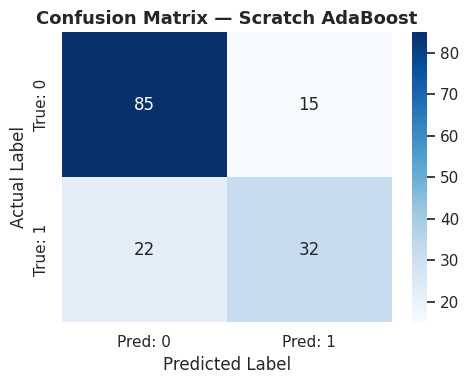

📊 Confusion matrix plotted.


In [12]:
# ── Confusion Matrix ───────────────────────────────────────────
cm_scratch = confusion_matrix(y_test, y_pred_scratch)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_scratch, annot=True, fmt='d', cmap='Blues',
    xticklabels=["Pred: 0", "Pred: 1"],
    yticklabels=["True: 0", "True: 1"],
    ax=ax
)
ax.set_title("Confusion Matrix — Scratch AdaBoost", fontsize=13, fontweight='bold')
ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("cm_scratch.png", dpi=120, bbox_inches='tight')
plt.show()
print("📊 Confusion matrix plotted.")


---
## 🤖 Part 3: Scikit-Learn Implementation — GradientBoostingClassifier

### How Scikit-Learn Implements Boosting

Scikit-Learn's `GradientBoostingClassifier` implements **Friedman's Gradient Boosting Machine** — a generalization of AdaBoost that works in function space using gradient descent. Key differences from our scratch AdaBoost:

| Aspect | Scratch AdaBoost | Sklearn GBM |
|---|---|---|
| **Core mechanism** | Reweights samples (exponential loss) | Fits trees to negative gradients of any loss |
| **Loss function** | Hardcoded: exponential | Configurable: log_loss, deviance, exponential |
| **Weak learner depth** | Stumps (depth=1) | Shallow trees (default max_depth=3) |
| **Initialization** | Uniform sample weights | Constant prediction = log-odds of positive class |
| **Prediction** | Weighted vote (sign) | Log-odds → sigmoid → probability |
| **Regularization** | Learning rate only | Learning rate + subsample + max_depth + min_samples |

### Why Use the Library?

- **Speed:** Cython-compiled trees with optimized histogram-based split finding.
- **Robustness:** Built-in handling of edge cases (min_samples_leaf, min_impurity_decrease).
- **Extensibility:** Integrates with sklearn Pipelines, GridSearchCV, and SHAP.
- **Reliability:** Thousands of real-world deployments have hardened the code.


### Cell 10: Train & Evaluate GradientBoostingClassifier

In [13]:
# ── Train Scikit-Learn GBM ────────────────────────────────────
# Note: GBM doesn't require feature scaling (tree-based splits are scale-invariant)
# We use unscaled X_train / X_test here.

sklearn_gbc = GradientBoostingClassifier(
    n_estimators   = 100,          # Number of boosting rounds
    learning_rate  = 0.1,          # Shrinkage: scale each tree's contribution
    max_depth      = 3,            # Shallow trees → low-variance weak learners
    subsample      = 0.8,          # Row subsampling: Stochastic GBM, reduces overfitting
    random_state   = 42
)

sklearn_gbc.fit(X_train, y_train)
print("✅ GradientBoostingClassifier trained.")

# ── Predictions ────────────────────────────────────────────────
y_pred_skl  = sklearn_gbc.predict(X_test)
y_proba_skl = sklearn_gbc.predict_proba(X_test)[:, 1]

acc_skl = accuracy_score(y_test, y_pred_skl)
auc_skl = roc_auc_score(y_test, y_proba_skl)

print(f"\n── Sklearn GBM Results ──────────────────────────────────────")
print(f"   Accuracy : {acc_skl:.4f}")
print(f"   AUC-ROC  : {auc_skl:.4f}")
print(f"\n── Classification Report ────────────────────────────────────")
print(classification_report(y_test, y_pred_skl, target_names=["Non-Diabetic", "Diabetic"]))


✅ GradientBoostingClassifier trained.

── Sklearn GBM Results ──────────────────────────────────────
   Accuracy : 0.7403
   AUC-ROC  : 0.8148

── Classification Report ────────────────────────────────────
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.82      0.80       100
    Diabetic       0.64      0.59      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



In [14]:
# ── Side-by-Side Comparison ───────────────────────────────────
print("═" * 52)
print(f"{'Metric':<20} {'Scratch AdaBoost':>15} {'Sklearn GBM':>15}")
print("─" * 52)
print(f"{'Accuracy':<20} {acc_scratch:>15.4f} {acc_skl:>15.4f}")
print(f"{'AUC-ROC':<20} {auc_scratch:>15.4f} {auc_skl:>15.4f}")
print("═" * 52)
print("\n💡 Observations:")
print("   • GBM uses gradient-based optimization on log-loss → often higher AUC")
print("   • AdaBoost uses exponential loss → more sensitive to label noise")
print("   • Both capture non-linear feature interactions that logistic regression misses")


════════════════════════════════════════════════════
Metric               Scratch AdaBoost     Sklearn GBM
────────────────────────────────────────────────────
Accuracy                      0.7597          0.7403
AUC-ROC                       0.8169          0.8148
════════════════════════════════════════════════════

💡 Observations:
   • GBM uses gradient-based optimization on log-loss → often higher AUC
   • AdaBoost uses exponential loss → more sensitive to label noise
   • Both capture non-linear feature interactions that logistic regression misses


---
### Cell 11: Visualizations

**Plot 1 — ROC Curves:** Compare both models' discrimination ability across all decision thresholds.  
**Plot 2 — Feature Importances:** Which features drive the GBM's predictions?  
**Plot 3 — AdaBoost Training Error Curve:** How weighted error evolves across boosting rounds.


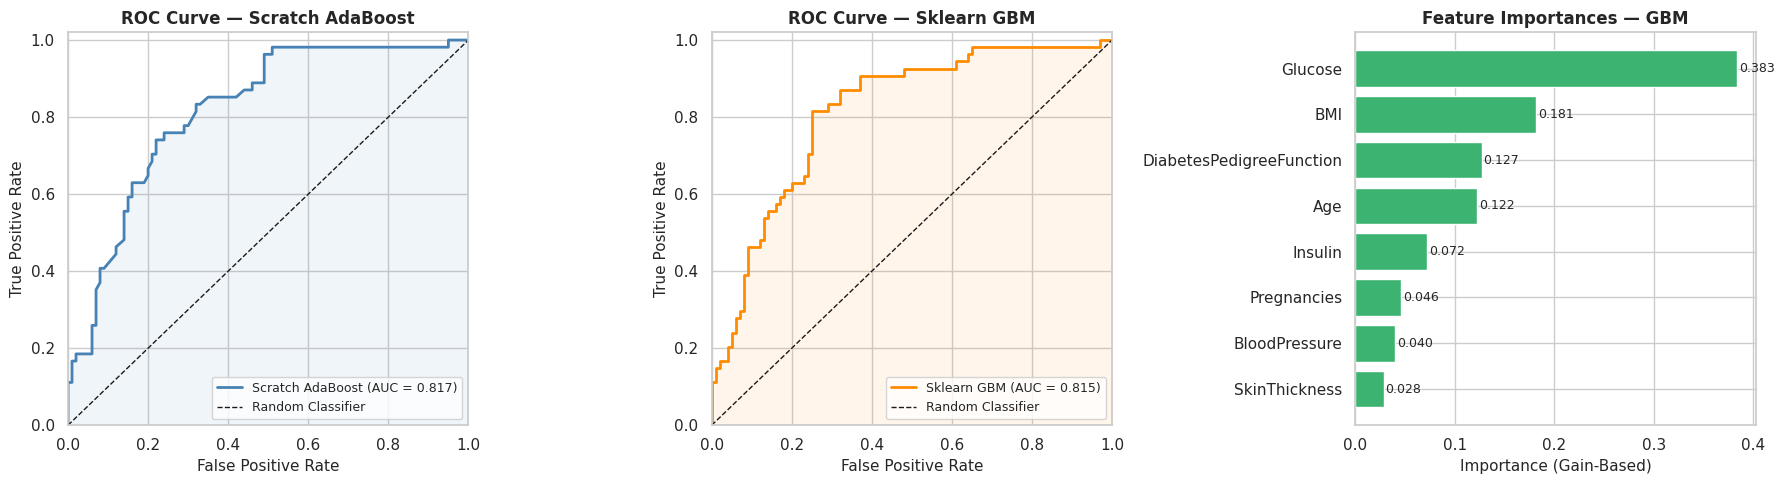

📊 ROC curves and feature importances plotted.

💡 Glucose and BMI dominate — consistent with medical literature on diabetes risk.


In [15]:
# ── Plot 1: ROC Curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC — Scratch AdaBoost
fpr_s, tpr_s, _ = roc_curve(y_test, y_proba_scratch)
axes[0].plot(fpr_s, tpr_s, color='steelblue', lw=2,
             label=f'Scratch AdaBoost (AUC = {auc_scratch:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].fill_between(fpr_s, tpr_s, alpha=0.08, color='steelblue')
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("ROC Curve — Scratch AdaBoost", fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

# ROC — Sklearn GBM
fpr_g, tpr_g, _ = roc_curve(y_test, y_proba_skl)
axes[1].plot(fpr_g, tpr_g, color='darkorange', lw=2,
             label=f'Sklearn GBM (AUC = {auc_skl:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr_g, tpr_g, alpha=0.08, color='darkorange')
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].set_title("ROC Curve — Sklearn GBM", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])

# ── Plot 2: Feature Importances ────────────────────────────────
importances = sklearn_gbc.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

axes[2].barh(feat_df['Feature'], feat_df['Importance'], color='mediumseagreen', edgecolor='white')
axes[2].set_xlabel("Importance (Gain-Based)", fontsize=11)
axes[2].set_title("Feature Importances — GBM", fontsize=12, fontweight='bold')
for i, val in enumerate(feat_df['Importance']):
    axes[2].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("roc_and_importance.png", dpi=130, bbox_inches='tight')
plt.show()
print("📊 ROC curves and feature importances plotted.")
print("\n💡 Glucose and BMI dominate — consistent with medical literature on diabetes risk.")


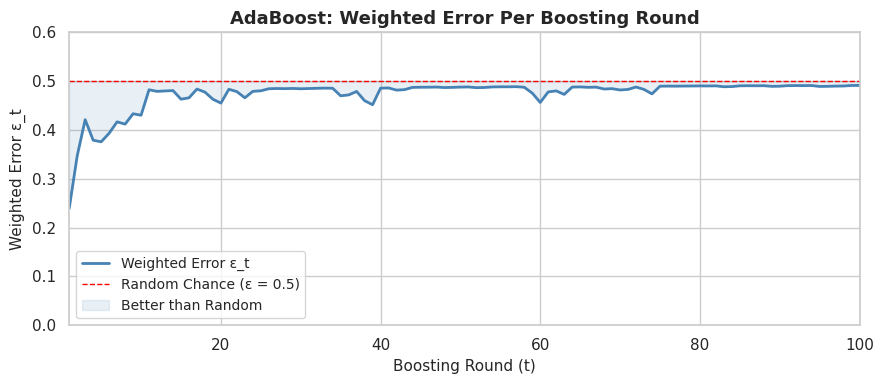

📊 Training error curve plotted.

💡 All stumps have ε_t < 0.5 — each is better than random, justifying Boosting's convergence.


In [16]:
# ── Plot 3: AdaBoost Training Error per Round ─────────────────
fig, ax = plt.subplots(figsize=(9, 4))

rounds = np.arange(1, len(scratch_model.train_errors) + 1)
ax.plot(rounds, scratch_model.train_errors, color='steelblue', lw=2, label='Weighted Error ε_t')
ax.axhline(y=0.5, color='red', linestyle='--', lw=1, label='Random Chance (ε = 0.5)')
ax.fill_between(rounds, scratch_model.train_errors, 0.5,
                where=[e < 0.5 for e in scratch_model.train_errors],
                alpha=0.12, color='steelblue', label='Better than Random')

ax.set_xlabel("Boosting Round (t)", fontsize=11)
ax.set_ylabel("Weighted Error ε_t", fontsize=11)
ax.set_title("AdaBoost: Weighted Error Per Boosting Round", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim([0, 0.6])
ax.set_xlim([1, len(rounds)])

plt.tight_layout()
plt.savefig("adaboost_error_curve.png", dpi=130, bbox_inches='tight')
plt.show()
print("📊 Training error curve plotted.")
print("\n💡 All stumps have ε_t < 0.5 — each is better than random, justifying Boosting's convergence.")


---
## 🎛️ Part 4: Hyperparameter Experiments

### Key Hyperparameters in Gradient Boosting

| Hyperparameter | Effect | Typical Range |
|---|---|---|
| `n_estimators` | More rounds → lower bias, but overfitting risk if too many | 50–1000 |
| `learning_rate` | Scales each tree's contribution; small η needs more trees | 0.01–0.3 |
| `max_depth` | Controls weak learner complexity; deeper = more variance | 2–8 |
| `subsample` | Fraction of rows sampled per tree; < 1.0 introduces randomness (Stochastic GBM) | 0.5–1.0 |
| `min_samples_leaf` | Minimum samples in a leaf; higher = smoother, less overfit | 1–50 |

### Practical Tuning Strategy

1. **Start with a moderate learning rate (0.1) and find the right n_estimators via cross-validation.**
2. **Once n_estimators is fixed, reduce learning rate and proportionally increase n_estimators.**
3. **Tune tree complexity** (max_depth, min_samples_leaf) to control overfitting.
4. **Always use stratified cross-validation** for imbalanced classification tasks.
5. **Monitor both train and validation loss** — divergence = overfitting.

> 🔑 **Interview Tip:** Learning rate and n_estimators must be tuned jointly, not independently. Treating them as independent is one of the most common candidate mistakes.


### Cell 13: Experiment 1 — n_estimators & Experiment 2 — learning_rate vs max_depth

In [17]:
# ── Experiment 1: Effect of n_estimators on CV AUC ──────────
np.random.seed(42)

n_estimators_range = [10, 25, 50, 75, 100, 150, 200, 300]
cv_auc_mean = []
cv_auc_std  = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running cross-validation across n_estimators values...")
for n in n_estimators_range:
    gbc = GradientBoostingClassifier(
        n_estimators=n, learning_rate=0.1, max_depth=3,
        subsample=0.8, random_state=42
    )
    scores = cross_val_score(gbc, X_train, y_train, cv=skf,
                             scoring='roc_auc', n_jobs=-1)
    cv_auc_mean.append(scores.mean())
    cv_auc_std.append(scores.std())
    print(f"  n_estimators={n:4d} | CV AUC = {scores.mean():.4f} ± {scores.std():.4f}")

best_n = n_estimators_range[np.argmax(cv_auc_mean)]
print(f"\n🏆 Best n_estimators: {best_n} (CV AUC = {max(cv_auc_mean):.4f})")


Running cross-validation across n_estimators values...
  n_estimators=  10 | CV AUC = 0.8293 ± 0.0268


  n_estimators=  25 | CV AUC = 0.8324 ± 0.0191


  n_estimators=  50 | CV AUC = 0.8359 ± 0.0201


  n_estimators=  75 | CV AUC = 0.8249 ± 0.0187


  n_estimators= 100 | CV AUC = 0.8208 ± 0.0185


  n_estimators= 150 | CV AUC = 0.8151 ± 0.0217


  n_estimators= 200 | CV AUC = 0.8142 ± 0.0211


  n_estimators= 300 | CV AUC = 0.8029 ± 0.0271

🏆 Best n_estimators: 50 (CV AUC = 0.8359)



Running learning_rate × max_depth grid search...


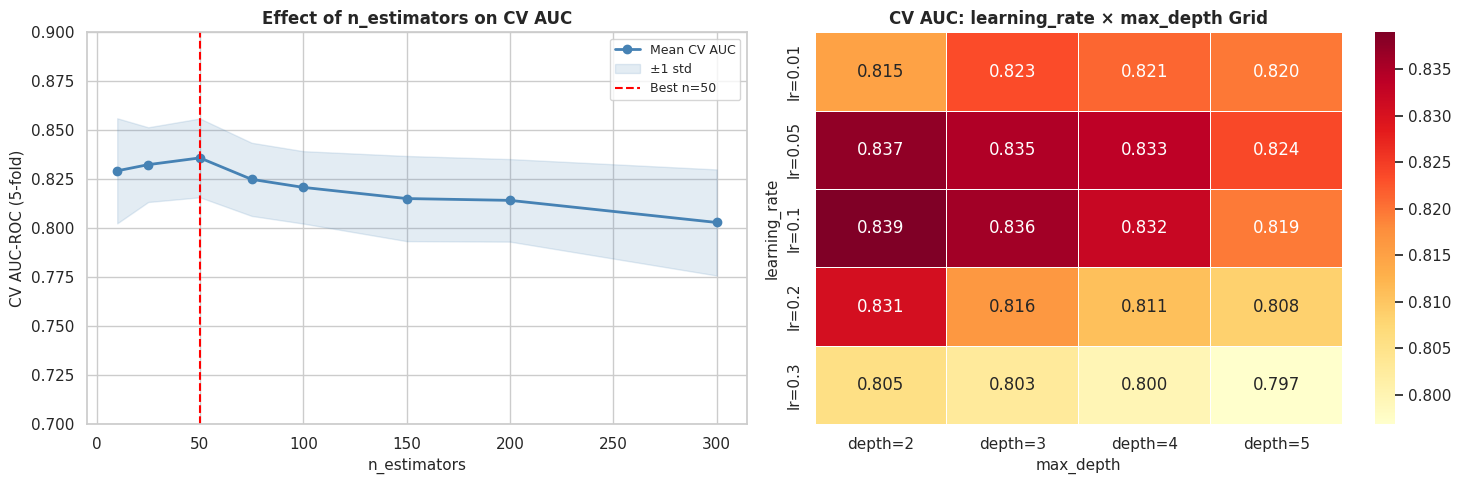


🏆 Best configuration: learning_rate=0.1, max_depth=2
   Grid AUC = 0.8389

💡 Low learning_rate + moderate depth usually generalizes best.
   High depth + high learning_rate → overfitting (darker cells in top-right).


In [18]:
# ── Plot: n_estimators vs CV AUC ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cv_auc_mean_arr = np.array(cv_auc_mean)
cv_auc_std_arr  = np.array(cv_auc_std)

axes[0].plot(n_estimators_range, cv_auc_mean_arr, 'o-', color='steelblue',
             lw=2, ms=6, label='Mean CV AUC')
axes[0].fill_between(
    n_estimators_range,
    cv_auc_mean_arr - cv_auc_std_arr,
    cv_auc_mean_arr + cv_auc_std_arr,
    alpha=0.15, color='steelblue', label='±1 std'
)
axes[0].axvline(x=best_n, color='red', linestyle='--', lw=1.5,
                label=f'Best n={best_n}')
axes[0].set_xlabel("n_estimators", fontsize=11)
axes[0].set_ylabel("CV AUC-ROC (5-fold)", fontsize=11)
axes[0].set_title("Effect of n_estimators on CV AUC", fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim([0.70, 0.90])

# ── Experiment 2: learning_rate × max_depth Grid ──────────────
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
max_depths     = [2, 3, 4, 5]

grid_results = np.zeros((len(learning_rates), len(max_depths)))

print("\nRunning learning_rate × max_depth grid search...")
for i, lr in enumerate(learning_rates):
    for j, md in enumerate(max_depths):
        gbc_g = GradientBoostingClassifier(
            n_estimators=best_n, learning_rate=lr,
            max_depth=md, subsample=0.8, random_state=42
        )
        scores = cross_val_score(gbc_g, X_train, y_train, cv=skf,
                                 scoring='roc_auc', n_jobs=-1)
        grid_results[i, j] = scores.mean()

# Plot heatmap
sns.heatmap(
    grid_results,
    annot=True, fmt='.3f', cmap='YlOrRd',
    xticklabels=[f'depth={d}' for d in max_depths],
    yticklabels=[f'lr={lr}' for lr in learning_rates],
    ax=axes[1], linewidths=0.5
)
axes[1].set_title("CV AUC: learning_rate × max_depth Grid", fontsize=12, fontweight='bold')
axes[1].set_xlabel("max_depth", fontsize=11)
axes[1].set_ylabel("learning_rate", fontsize=11)

plt.tight_layout()
plt.savefig("hyperparam_experiments.png", dpi=130, bbox_inches='tight')
plt.show()

best_idx   = np.unravel_index(np.argmax(grid_results), grid_results.shape)
best_lr    = learning_rates[best_idx[0]]
best_depth = max_depths[best_idx[1]]
print(f"\n🏆 Best configuration: learning_rate={best_lr}, max_depth={best_depth}")
print(f"   Grid AUC = {grid_results[best_idx]:.4f}")
print("\n💡 Low learning_rate + moderate depth usually generalizes best.")
print("   High depth + high learning_rate → overfitting (darker cells in top-right).")


---
## 🎯 Part 5: Interview Corner

### FAANG-Level Questions & Model Answers

---

#### Q1. How does Gradient Boosting differ from AdaBoost?

**Key points to hit:**
- Both are sequential additive ensembles — that's the common ground.
- AdaBoost reweights *samples* using exponential loss; α computed analytically.
- GBM fits each tree to the *negative gradient* of any differentiable loss.
- **The unifying insight:** AdaBoost is a special case of GBM under exponential loss (Friedman, 2001).
- GBM generalizes to regression, ranking, survival — AdaBoost is classification-only.

❌ **Common mistake:** Saying they're "basically the same." Interviewers want the functional gradient descent framing.

---

#### Q2. Why does Boosting reduce bias rather than variance?

**Key points to hit:**
- Each round corrects the *systematic* errors of the current ensemble.
- The residuals shrink toward zero → bias decreases round by round.
- Contrast with Bagging: parallel models average out *random* errors → reduces variance.
- **Boosting CAN increase variance** if: too many rounds, deep trees, noisy labels.
- Controls: early stopping, learning rate, max_depth, subsampling.

❌ **Common mistake:** Saying Boosting reduces both equally. It primarily targets bias.

---

#### Q3. What happens if you set the learning rate too high or too low?

**Key points to hit:**
- **Too high (η → 1):** Large steps → overshoots the error minimum → high variance, overfitting.
- **Too low (η → 0.001):** Very cautious steps → needs thousands of trees → slow training, may underfit with fixed n_estimators.
- **The joint tuning rule:** Low η + high n_estimators + early stopping = best generalization.
- Analogy: Learning rate in GBM is exactly like step size in gradient descent — same tradeoffs.

❌ **Common mistake:** Tuning learning rate and n_estimators independently.

---

#### Q4. How does XGBoost differ from Scikit-Learn's GradientBoostingClassifier?

**Key points to hit:**
- **Second-order gradients:** XGBoost uses both gradient and Hessian for more accurate leaf scores.
- **Explicit regularization:** L1 (α) and L2 (λ) penalties on leaf weights baked into the objective.
- **System optimizations:** Cache-aware histogram binning, parallel split-finding, GPU support.
- **Sparsity-aware:** Native handling of missing values and sparse features.
- **Column subsampling:** Per-tree and per-split feature sampling (like Random Forest's feature randomness).
- sklearn GBM is a reference implementation; XGBoost is production-grade.

❌ **Common mistake:** Saying XGBoost is a different algorithm. It's GBM with engineering improvements.

---

#### Q5. How would you handle overfitting in a production GBM model?

**Key points to hit (prioritized by effectiveness):**
1. **Early stopping** on a validation set — most important tool.
2. **Lower learning_rate** + more n_estimators (shrinkage effect).
3. **Reduce max_depth** (shallower trees = lower-variance weak learners).
4. **Increase min_samples_leaf** (smoother leaf predictions).
5. **subsample < 1.0** (Stochastic GBM — introduces beneficial randomness).
6. **L1/L2 regularization** (XGBoost/LightGBM only).
7. **Clean labels** — mislabeled data is amplified by Boosting's reweighting.

❌ **Common mistake:** Only mentioning n_estimators reduction without explaining early stopping or the learning rate tradeoff.

---

> 💼 **Meta-tip for interviews:** Structure every Boosting answer around:  
> **(1) Mechanism → (2) Why it works → (3) What can go wrong → (4) How to fix it.**  
> Interviewers at FAANG companies want to see that you understand the *failure modes*, not just the happy path.


---
## ✅ Key Takeaways

1. **Boosting is sequential, error-correcting ensemble learning.**  
   Each weak learner focuses on the mistakes of the current ensemble — via sample reweighting (AdaBoost) or gradient fitting (GBM). The final model is a weighted additive sum of all weak learners.

2. **Gradient Boosting is functional gradient descent.**  
   Fitting trees to pseudo-residuals (negative gradients of the loss) generalizes Boosting to any differentiable objective. AdaBoost is the special case under exponential loss. This unification is the most important conceptual idea in the field.

3. **From-scratch implementation reveals the machinery that libraries hide.**  
   Weight normalization, alpha clipping, ±1 label encoding, and the sample_weight interface are all invisible in sklearn — but understanding them is what separates strong interview candidates from weak ones.

4. **Learning rate and n_estimators must always be tuned jointly.**  
   Low η + high n_estimators + early stopping is the gold-standard production recipe. Treating them as independent hyperparameters is the most common practitioner mistake.

5. **Boosting excels on structured/tabular data; interpretability requires care.**  
   Gain-based feature importance is fast but biased toward high-cardinality features. In production, prefer SHAP values for reliable attribution — and always validate that Glucose and BMI (or your domain's equivalent) dominate, as a sanity check against data leakage.

---
*Notebook prepared as part of the MIT ML curriculum. Dataset: Pima Indians Diabetes (Kaggle/UCI). All implementations use NumPy and Scikit-Learn only.*
